**BIBLIOTECAS**

In [80]:
# IMPORTAÇÃO DE BIBLIOTECAS\+
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.validation import check_is_fitted
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    chi2
)

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from joblib import Memory

**CARREGAMENTO DOS DADOS**

In [81]:

df_train = pd.read_parquet("datasense_full_train_1sec.parquet")
df_test  = pd.read_parquet("datasense_full_test_1sec.parquet")

print("Train:", df_train.shape)
print("Test :", df_test.shape)

Train: (170393, 115)
Test : (56798, 115)


**DEFINIÇÃO DO TARGET**

In [82]:

# TARGET
# label1 = variável original do dataset
# "attack" = comportamento malicioso (classe positiva = 1)
# qualquer outro valor = normal (classe negativa = 0)

# CONVERSÃO PARA PROBLEMA BINÁRIO
y_train = (df_train["label1"] == "attack").astype(int)
y_test  = (df_test["label1"] == "attack").astype(int)


# VERIFICAÇÃO DA DISTRIBUIÇÃO
print("✔ Distribuição no treino:")
print(y_train.value_counts())

print("\n✔ Distribuição no teste:")
print(y_test.value_counts())

✔ Distribuição no treino:
label1
0    102600
1     67793
Name: count, dtype: int64

✔ Distribuição no teste:
label1
0    34200
1    22598
Name: count, dtype: int64


In [83]:
# TARGET (label1 → binário)

target_col = "label1"

y_train = (df_train[target_col] == "attack").astype(int)
y_test  = (df_test[target_col] == "attack").astype(int)

**LIMPEZA E FEATURES**

In [84]:
cols_to_drop = ["label1", "label2", "label3", "label4", "label_extended"]

X_train = df_train.drop(columns=cols_to_drop)
X_test  = df_test.drop(columns=cols_to_drop)

# One-hot encoding
X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

# alinhar colunas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Features:", X_train.shape)

Features: (170393, 149)


**ANÁLISE DAS CLASSES**

✔ Distribuição no TREINO:
label1
0    102600
1     67793
Name: count, dtype: int64

✔ Distribuição no TESTE:
label1
0    34200
1    22598
Name: count, dtype: int64


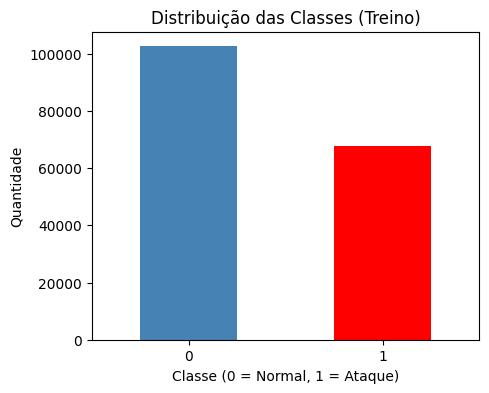


Interpretação:
- Classe 0 = tráfego normal
- Classe 1 = ataques (anomalias IIoT)
- Dataset possivelmente desbalanceado → justificar uso de class_weight='balanced'


In [85]:
# ANÁLISE DE CLASSES — DETECÇÃO DE ATAQUES IIoT

# CONTAGEM DAS CLASSES
train_counts = y_train.value_counts()
test_counts  = y_test.value_counts()

print("✔ Distribuição no TREINO:")
print(train_counts)

print("\n✔ Distribuição no TESTE:")
print(test_counts)

# VISUALIZAÇÃO
plt.figure(figsize=(5,4))

train_counts.plot(kind='bar', color=['steelblue', 'red'])

plt.title("Distribuição das Classes (Treino)")
plt.xlabel("Classe (0 = Normal, 1 = Ataque)")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)

plt.show()


# INTERPRETAÇÃO (IMPORTANTE PARA ARTIGO)
print("\nInterpretação:")
print("- Classe 0 = tráfego normal")
print("- Classe 1 = ataques (anomalias IIoT)")
print("- Dataset possivelmente desbalanceado → justificar uso de class_weight='balanced'")

**REMOÇÃO DE COLINEARIDADE**

In [86]:
# SELEÇÃO DE FEATURES (LIGHTWEIGHT - SEM VIF)

from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

# Remove features constantes
vt = VarianceThreshold(threshold=0.0)
X_train_vt = vt.fit_transform(X_train)
X_test_vt = vt.transform(X_test)

# Normalização (necessário para chi2)
scaler_fs = MinMaxScaler()
X_train_fs = scaler_fs.fit_transform(X_train_vt)
X_test_fs = scaler_fs.transform(X_test_vt)

#Seleção estatística (Top K features)
selector = SelectKBest(score_func=chi2, k=120)

X_train_sel = selector.fit_transform(X_train_fs, y_train)
X_test_sel = selector.transform(X_test_fs)

print("✔ Features removidas:", X_train.shape[1] - X_train_sel.shape[1])
print("✔ Features finais:", X_train_sel.shape[1])

✔ Features removidas: 29
✔ Features finais: 120


**PIPELINE DE PRÉ-PROCESSAMENTO E MODELO (SEM TREINO)**

In [87]:
memory = Memory(location="./cache_pipeline", verbose=0)

pipeline = Pipeline([

    # Remove features constantes
    ('var_filter', VarianceThreshold(threshold=0.0)),

    # Normalização necessária para chi²
    ('scaler', MinMaxScaler()),

    # Seleção de features
    ('feature_select', SelectKBest(score_func=chi2, k=120)),

    # Modelo final (ElasticNet ativo)
    ('model', LogisticRegression(
        solver='saga',
        penalty='elasticnet',
        l1_ratio=0.5,
        C=0.7,
        max_iter=2000,
        tol=1e-3,
        class_weight={0: 1, 1: 1.35},
        random_state=42
    ))
], memory=memory)

**GRIDSEARCHCV (OTIMIZAÇÃO DO MODELO)**

In [88]:
# DEFINIÇÃO DO ESPAÇO DE HIPERPARÂMETROS
# Versão otimizada e compatível com sklearn >= 1.8 (sem FutureWarning)

param_grid = {

    # força de regularização
    'model__C': [0.3, 0.7, 1.0],

    # peso da classe positiva (ataques)
    'model__class_weight': [
        {0: 1, 1: 1.2},
        {0: 1, 1: 1.35}
    ],

    # ElasticNet regularization (L1 + L2)
    'model__l1_ratio': [0.5, 1.0]
}

# validação cruzada estratificada
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# GRID SEARCH
# Busca exaustiva sobre combinações do pipeline definido
grid = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    # Métrica principal otimizada para desbalanceamento
    scoring='f1',

    # Estratégia de validação cruzada
    cv=cv,

    # Utiliza todos os núcleos disponíveis para paralelização
    n_jobs=-1,

    # Exibe progresso do treinamento
    verbose=2
)

# TREINAMENTO COM BUSCA DE HIPERPARÂMETROS
# Ajusta pipeline completo (pré-processamento + modelo)
grid.fit(X_train, y_train)

# RESULTADOS DO MELHOR MODELO ENCONTRADO
print("Melhores parâmetros:", grid.best_params_)
print("Melhor F1:", grid.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\bruno.lima\Documents\Projeto IIOT\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Melhores parâmetros: {'model__C': 1.0, 'model__class_weight': {0: 1, 1: 1.35}, 'model__l1_ratio': 1.0}
Melhor F1: 0.86266965800501


**MODELO FINAL (BEST ESTIMATOR)**

In [89]:
# RECUPERA O MELHOR MODELO ENCONTRADO

best_model = grid.best_estimator_
print("Modelo otimizado carregado")

Modelo otimizado carregado


**VALIDAÇÃO CRUZADA**

In [90]:
# VALIDAÇÃO CRUZADA NO MODELO OTIMIZADO
# Avalia estabilidade do modelo final em dados de treino

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("F1 Scores:", scores)
print("F1 Médio:", scores.mean())
print("F1 Desvio Padrão:", scores.std())

F1 Scores: [0.85989527 0.86430125 0.86381246]
F1 Médio: 0.86266965800501
F1 Desvio Padrão: 0.0019719128437625006


**OTIMIZAÇÃO DE THRESHOLD**

In [91]:
# PROBABILIDADE DO MODELO (classe positiva = ataque)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Intervalo de busca do threshold
thresholds = np.linspace(0.1, 0.9, 50)

best_thresh = 0.5
best_f1 = 0

# BUSCA DO MELHOR LIMIAR BASEADO EM F1
for t in thresholds:

    y_temp = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Melhor threshold:", best_thresh)
print("Melhor F1:", best_f1)

Melhor threshold: 0.4591836734693878
Melhor F1: 0.8642928712822894


**PREDIÇÃO - DETECÇÃO DE ATAQUES**

In [92]:
# GARANTE QUE O MODELO FINAL FOI TREINADO
check_is_fitted(best_model)


# PROBABILIDADE DA CLASSE POSITIVA (ATAQUE)
y_prob = best_model.predict_proba(X_test)[:, 1]

# DEFINIÇÃO DO THRESHOLD OTIMIZADO
thresholds = np.linspace(0.1, 0.9, 50)

best_thresh = 0.5
best_f1 = 0

for t in thresholds:

    y_temp = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_temp)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Melhor threshold:", best_thresh)
print("Melhor F1:", best_f1)


# PREDIÇÃO FINAL USANDO THRESHOLD OTIMIZADO
y_pred = (y_prob >= best_thresh).astype(int)

# DATAFRAME FINAL DE RESULTADOS
df_result = X_test.copy()
df_result["Real"] = y_test.values
df_result["Predito"] = y_pred
df_result["Probabilidade"] = y_prob

# FILTRAGEM DE ATAQUES DETECTADOS
ataques_detectados = df_result[df_result["Predito"] == 1]

print("Total:", len(df_result))
print("Ataques reais:", df_result["Real"].sum())
print("Ataques detectados:", len(ataques_detectados))

# EXEMPLOS MAIS CONFIANTES (MAIOR PROBABILIDADE)
display(
    ataques_detectados.sort_values(
        "Probabilidade",
        ascending=False
    ).head(10)
)

Melhor threshold: 0.4591836734693878
Melhor F1: 0.8642928712822894
Total: 56798
Ataques reais: 22598
Ataques detectados: 18321


,network_fragmentation-score,network_fragmented-packets,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_interval-packets,network_ip-flags_avg,network_ip-flags_max,network_ip-flags_min,...,device_name_water-sensor,device_name_weather-sensor,device_name_wisenet-camera,device_name_yi-camera,device_type_control,device_type_infra,device_type_iot,Real,Predito,Probabilidade
11,0.0,0,20.0,20.0,20.0,0.0,0.149917,1.001498,2.0,0.0,...,False,False,False,False,True,False,False,1,1,1.0
56742,0.0,0,20.0,20.0,20.0,0.0,0.006737,0.000000,0.0,0.0,...,False,False,False,False,False,False,True,1,1,1.0
60,0.0,0,20.0,20.0,20.0,0.0,0.194873,1.003984,2.0,0.0,...,False,False,True,False,False,False,True,1,1,1.0
56724,0.0,0,20.0,20.0,20.0,0.0,0.321440,1.001929,2.0,0.0,...,False,False,False,False,False,True,False,1,1,1.0
56712,0.0,0,20.0,20.0,20.0,0.0,0.009851,0.000079,2.0,0.0,...,False,False,False,False,False,True,False,1,1,1.0
14316,0.0,0,20.0,20.0,20.0,0.0,0.009693,0.000019,2.0,0.0,...,False,False,False,False,False,False,True,1,1,1.0
14511,0.0,0,20.0,20.0,20.0,0.0,0.006715,1.997327,2.0,0.0,...,False,False,False,False,False,False,True,1,1,1.0
14561,0.0,0,20.0,20.0,20.0,0.0,0.149785,1.001490,2.0,0.0,...,False,False,False,False,True,False,False,1,1,1.0
14564,0.0,0,20.0,20.0,20.0,0.0,0.008958,0.018256,2.0,0.0,...,False,False,False,False,True,False,False,1,1,1.0
14575,0.0,0,20.0,20.0,20.0,0.0,0.225025,1.000999,2.0,0.0,...,False,False,False,False,False,False,True,1,1,1.0


**MÉTRICAS**

In [93]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9022324729744005

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     34200
           1       0.97      0.78      0.86     22598

    accuracy                           0.90     56798
   macro avg       0.92      0.88      0.89     56798
weighted avg       0.91      0.90      0.90     56798

ROC-AUC: 0.9139130921123797


**MATRIZ DE CONFUSÃO**

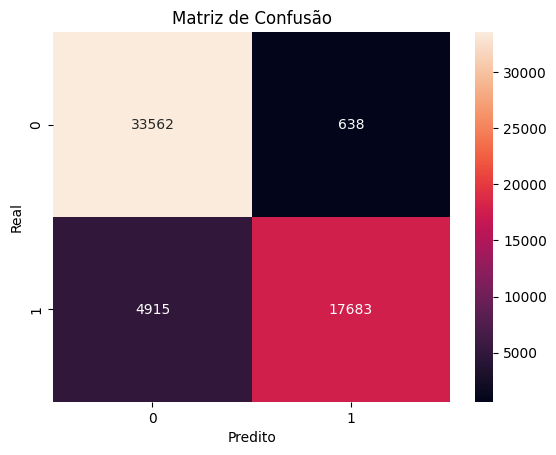

In [94]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

**CURVA ROC**

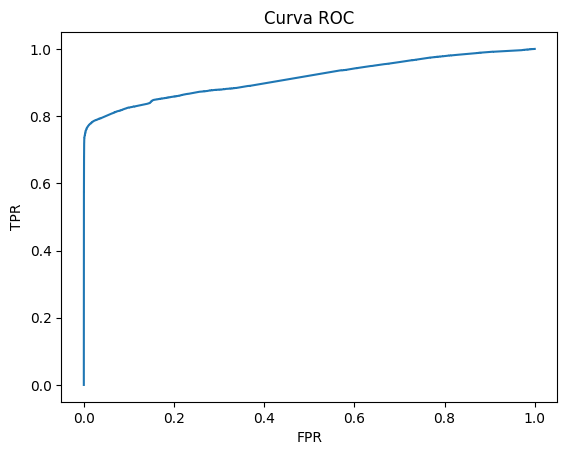

In [95]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

**INTERPRETABILIDADE DO MODELO - FEATURE IMPORTANCE**

In [96]:
# nomes originais das features (antes do pipeline)
feature_names = X_train.columns

# modelo final selecionado pelo GridSearchCV
model = best_model.named_steps['model']

# EXTRAÇÃO ROBUSTA DE COEFICIENTES
try:
    # caso padrão: LogisticRegression
    importance = model.coef_[0]

except AttributeError:
    # caso alternativo (ex: calibração de modelo)
    importance = model.base_estimator.coef_[0]

# VALIDAÇÃO

print("Features:", len(feature_names))
print("Importâncias:", len(importance))

min_len = min(len(feature_names), len(importance))

# DATAFRAME FINAL

feat_imp = pd.DataFrame({
    "Feature": feature_names[:min_len],
    "Importance": importance[:min_len]
})

feat_imp["Abs_Importance"] = feat_imp["Importance"].abs()
feat_imp = feat_imp.sort_values(by="Abs_Importance", ascending=False)

display(feat_imp.head(10))

Features: 149
Importâncias: 120


,Feature,Importance,Abs_Importance
16,network_ips_dst_count,31.552601,31.552601
27,network_packet-size_min,26.872577,26.872577
46,network_tcp-flags-syn_count,-25.280262,25.280262
28,network_packet-size_std_deviation,20.310691,20.310691
18,network_macs_all_count,-14.185137,14.185137
17,network_ips_src_count,-14.185137,14.185137
45,network_tcp-flags-rst_count,13.477729,13.477729
49,network_tcp-flags_max,7.067518,7.067518
50,network_tcp-flags_min,-6.155717,6.155717
37,network_ports_dst_count,6.057761,6.057761


**GRÁFICO DE IMPORTÂNCIA**

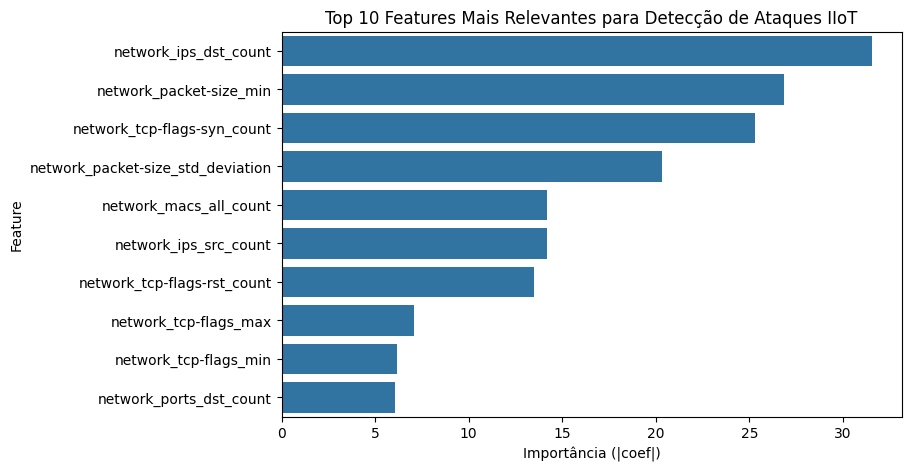

In [97]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Abs_Importance",
    y="Feature",
    data=feat_imp.head(10)
)

plt.title("Top 10 Features Mais Relevantes para Detecção de Ataques IIoT")
plt.xlabel("Importância (|coef|)")
plt.ylabel("Feature")

plt.show()